In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Paths
BASE_DIR   = '/home/abdul/sales-analytics-dashboard'
CLEAN_DATA = os.path.join(BASE_DIR, 'data', 'processed', 'clean_superstore.csv')
EXPORTS    = os.path.join(BASE_DIR, 'exports')

# Load data
df = pd.read_csv(CLEAN_DATA)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Global chart style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi']    = 150
plt.rcParams['font.size']     = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Data loaded:", df.shape)

✅ Data loaded: (9994, 28)


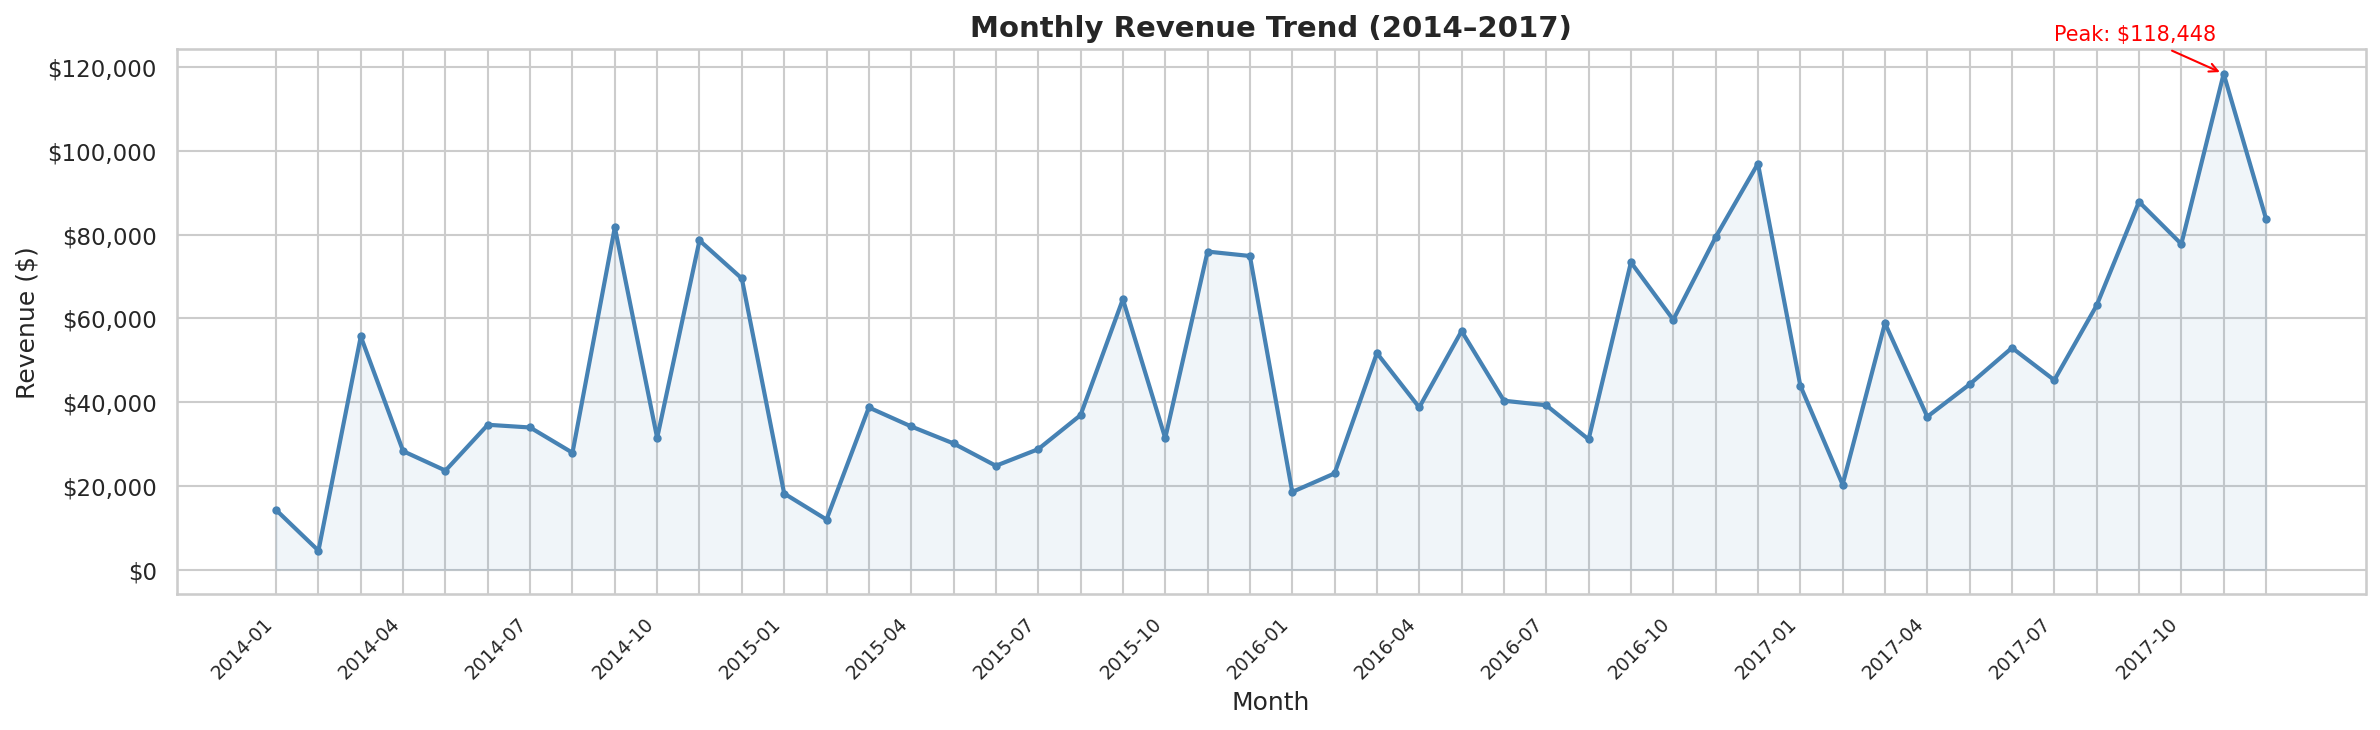

✅ Chart 1 saved


In [2]:
#Monthly revenue trend
# Aggregate monthly revenue
monthly = (
    df.groupby('YearMonth')['Sales']
    .sum()
    .reset_index()
    .rename(columns={'Sales': 'Revenue'})
)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(monthly['YearMonth'], monthly['Revenue'],
        color='steelblue', linewidth=2, marker='o', markersize=3)

ax.fill_between(monthly.index, monthly['Revenue'],
                alpha=0.08, color='steelblue')

# Highlight peaks
peak_idx = monthly['Revenue'].idxmax()
ax.annotate(
    f"Peak: ${monthly.loc[peak_idx,'Revenue']:,.0f}",
    xy=(peak_idx, monthly.loc[peak_idx,'Revenue']),
    xytext=(peak_idx - 4, monthly.loc[peak_idx,'Revenue'] + 8000),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=10
)

# Format x-axis — show every 3rd label to avoid crowding
labels = monthly['YearMonth'].tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    [l if i % 3 == 0 else '' for i, l in enumerate(labels)],
    rotation=45, ha='right', fontsize=9
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly Revenue Trend (2014–2017)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig(os.path.join(EXPORTS, 'chart1_monthly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

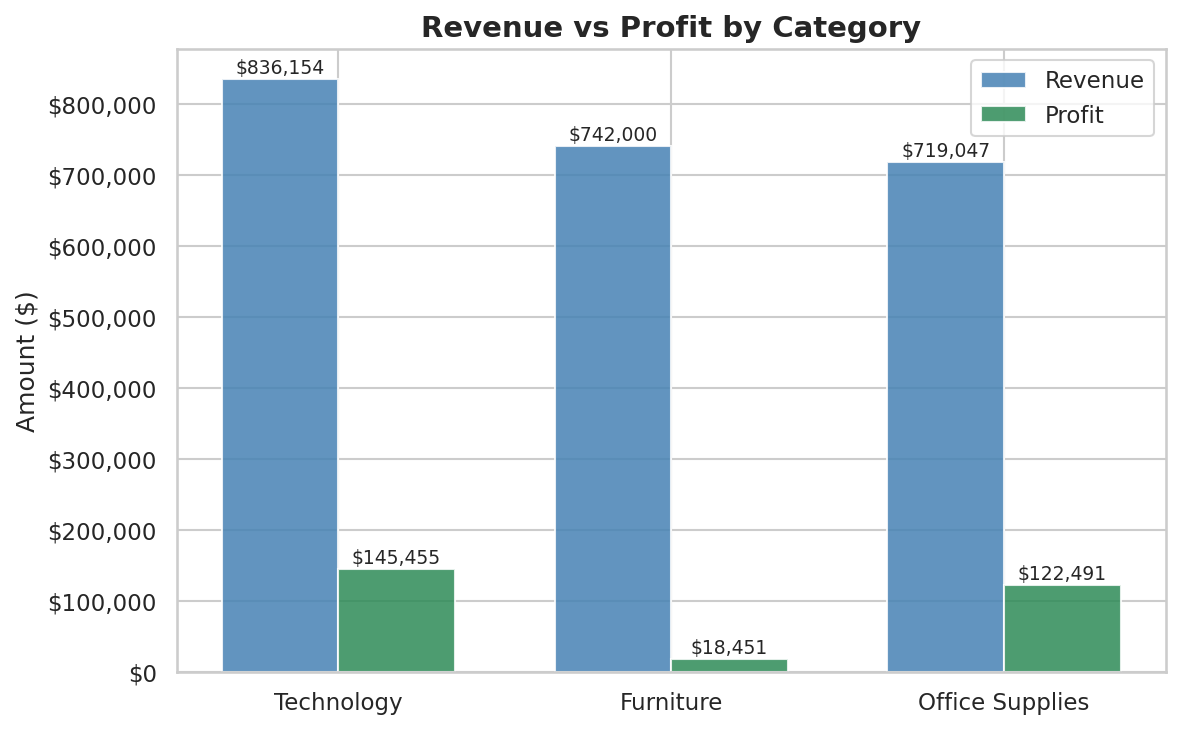

✅ Chart 2 saved


In [3]:
#Revenue by category (bar chart)
cat_sales = (
    df.groupby('Category')[['Sales', 'Profit']]
    .sum()
    .reset_index()
    .sort_values('Sales', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

x     = range(len(cat_sales))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], cat_sales['Sales'],
               width=width, label='Revenue', color='steelblue', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], cat_sales['Profit'],
               width=width, label='Profit', color='seagreen', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'${bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'${bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(cat_sales['Category'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Revenue vs Profit by Category')
ax.set_ylabel('Amount ($)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(EXPORTS, 'chart2_category_performance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

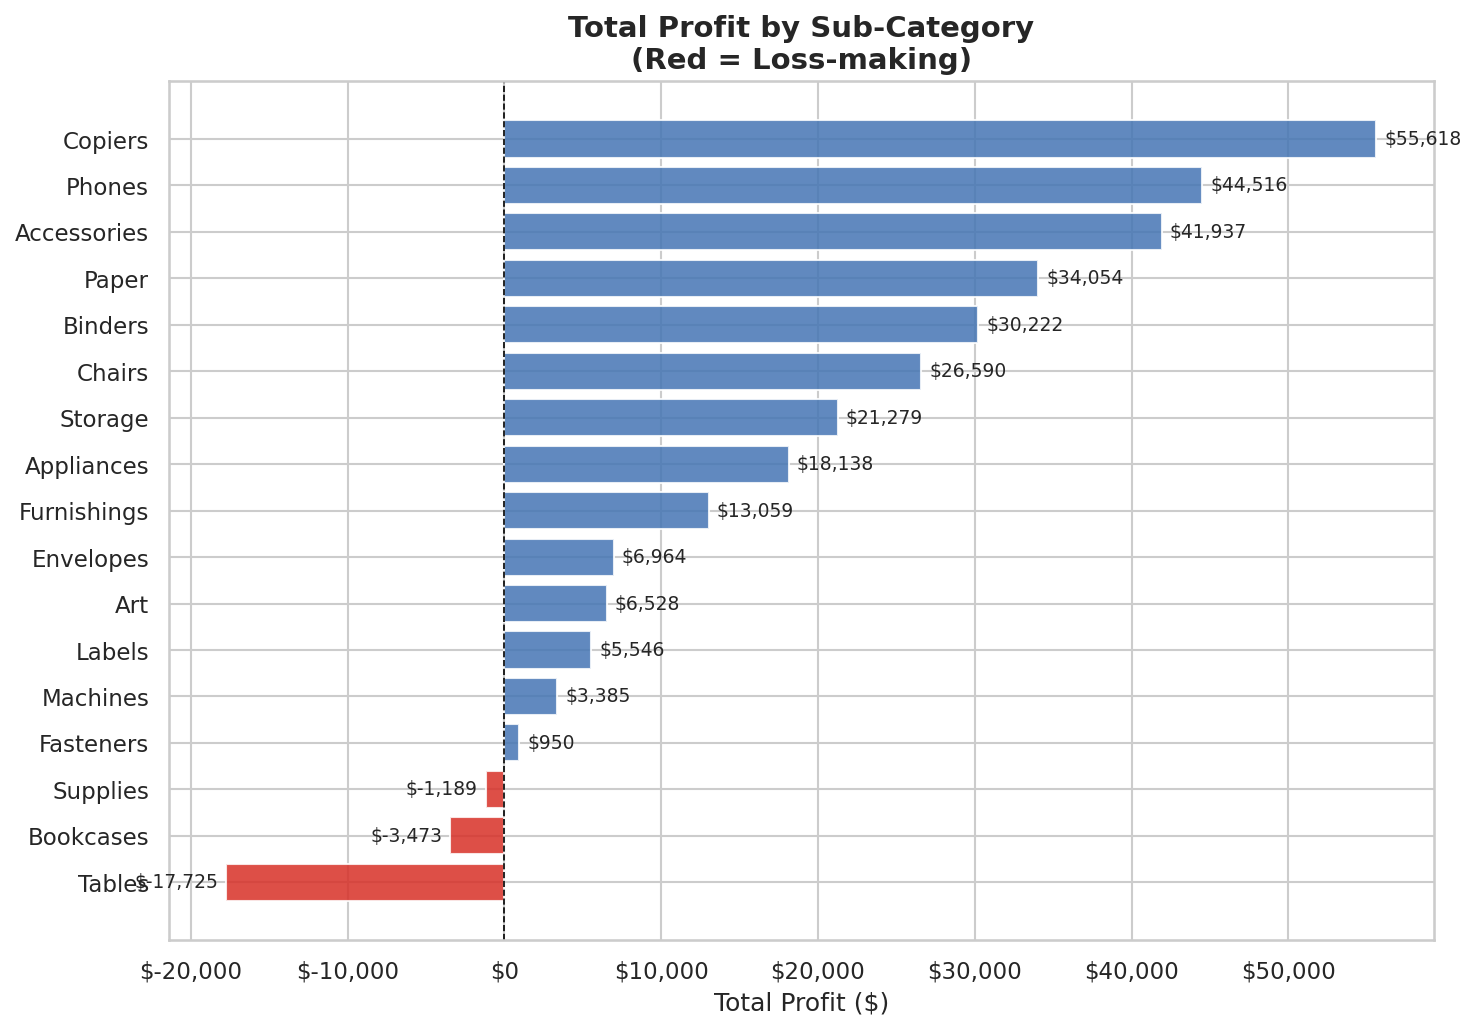

✅ Chart 3 saved


In [4]:
#Profit by sub-category (horizontal bar)
sub_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .reset_index()
    .sort_values('Profit', ascending=True)
)

# Color bars red for loss, blue for profit
colors = ['#d73027' if x < 0 else '#4575b4' for x in sub_profit['Profit']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(sub_profit['Sub-Category'], sub_profit['Profit'],
               color=colors, alpha=0.85, edgecolor='white')

# Add value labels
for bar, val in zip(bars, sub_profit['Profit']):
    ax.text(
        val + (500 if val >= 0 else -500),
        bar.get_y() + bar.get_height()/2,
        f'${val:,.0f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Total Profit by Sub-Category\n(Red = Loss-making)')
ax.set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.savefig(os.path.join(EXPORTS, 'chart3_subcategory_profit.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

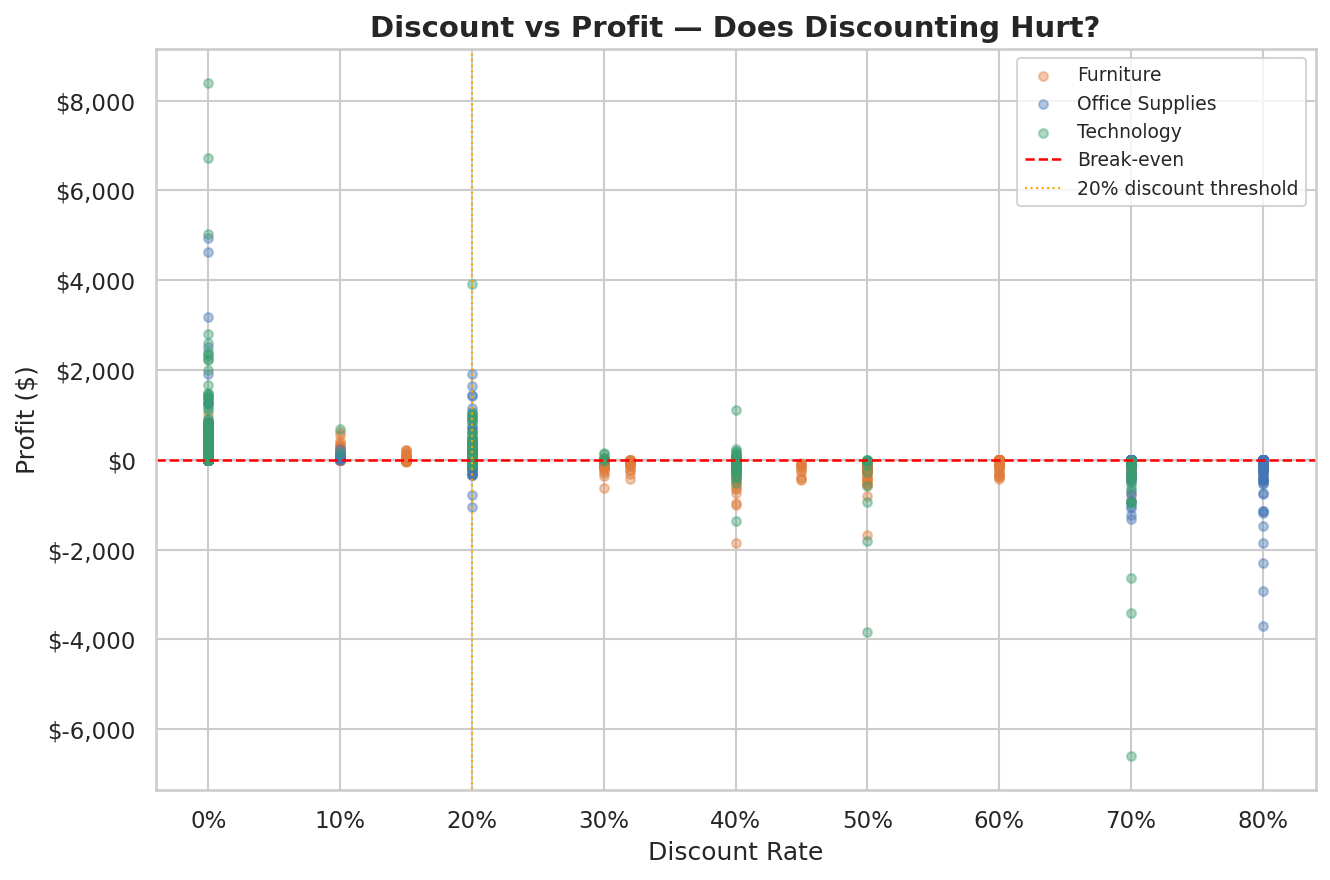

✅ Chart 4 saved


In [5]:
# Discount vs profit scatter
fig, ax = plt.subplots(figsize=(9, 6))

categories = df['Category'].unique()
colors_map = {'Furniture': '#e07b39', 'Office Supplies': '#4575b4', 'Technology': '#3a9e6e'}

for cat in categories:
    subset = df[df['Category'] == cat]
    ax.scatter(subset['Discount'], subset['Profit'],
               label=cat, alpha=0.4, s=18,
               color=colors_map[cat])

ax.axhline(0, color='red', linewidth=1.2, linestyle='--', label='Break-even')
ax.axvline(0.2, color='orange', linewidth=1, linestyle=':', label='20% discount threshold')

ax.set_title('Discount vs Profit — Does Discounting Hurt?')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(EXPORTS, 'chart4_discount_vs_profit.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

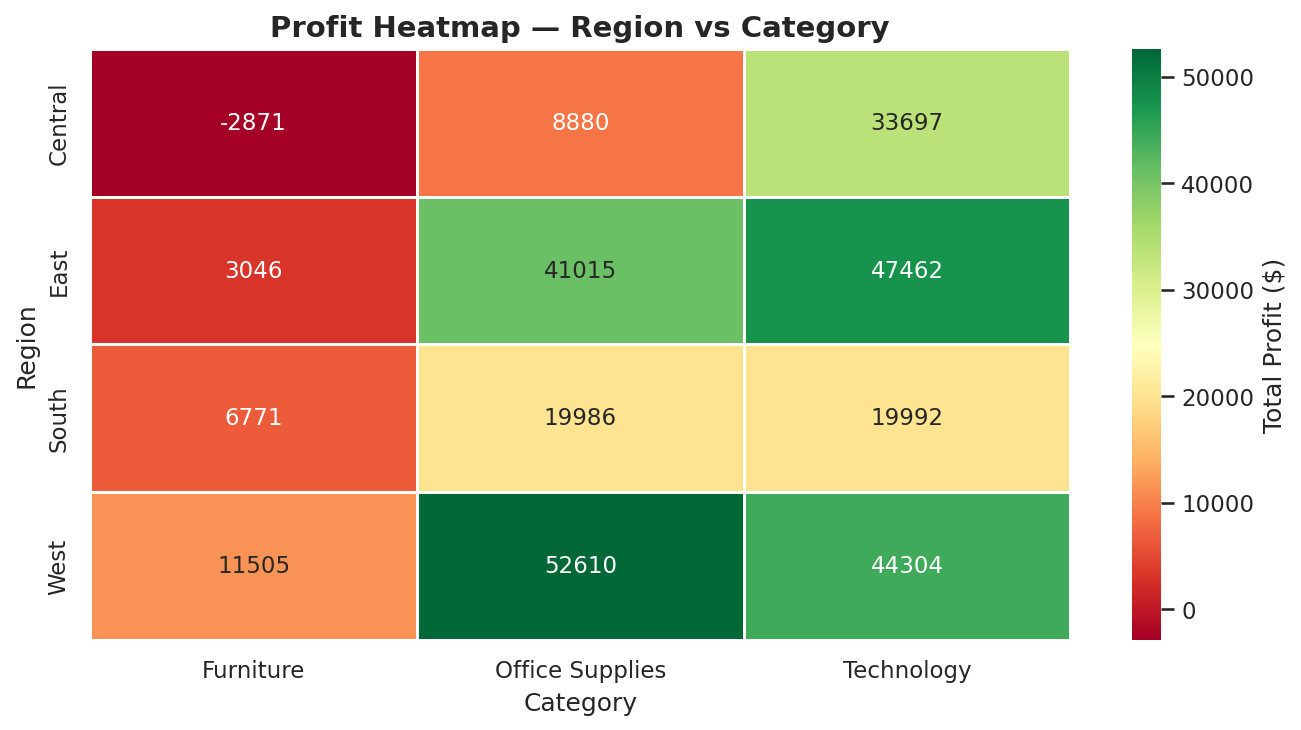

✅ Chart 5 saved


In [6]:
#Region and category heatmap
pivot = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
).round(0)

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Total Profit ($)'}
)

ax.set_title('Profit Heatmap — Region vs Category')
ax.set_xlabel('Category')
ax.set_ylabel('Region')

plt.tight_layout()
plt.savefig(os.path.join(EXPORTS, 'chart5_region_category_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")

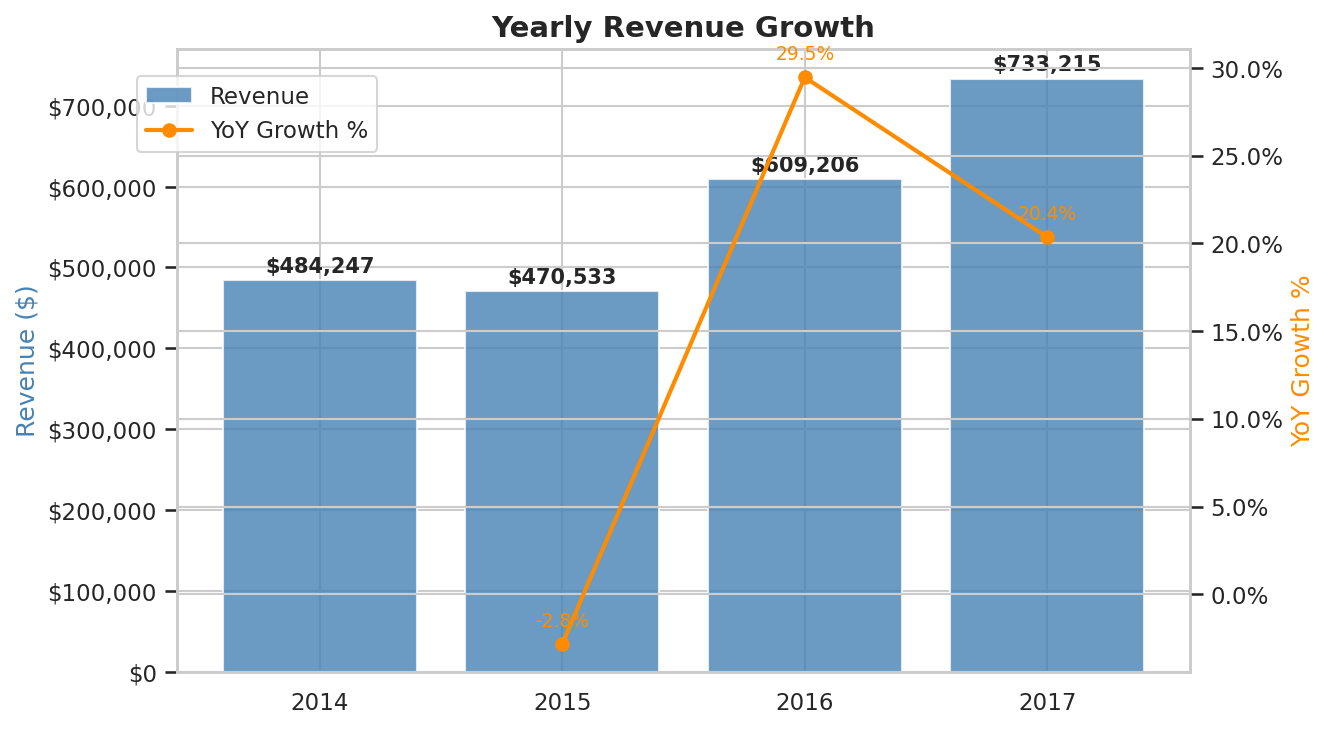

✅ Chart 6 saved


In [7]:
# Yearly revenue growth (bar)
yearly = (
    df.groupby('Year')[['Sales', 'Profit']]
    .sum()
    .reset_index()
)

# Calculate YoY growth %
yearly['Revenue Growth %'] = yearly['Sales'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart for revenue
bars = ax1.bar(yearly['Year'].astype(str), yearly['Sales'],
               color='steelblue', alpha=0.8, label='Revenue')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.set_title('Yearly Revenue Growth')

# Add revenue labels on bars
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5000,
             f'${bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Overlay growth % line
ax2 = ax1.twinx()
ax2.plot(yearly['Year'].astype(str),
         yearly['Revenue Growth %'],
         color='darkorange', marker='o',
         linewidth=2, label='YoY Growth %')

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.set_ylabel('YoY Growth %', color='darkorange')

# Add growth % labels
for i, (yr, val) in enumerate(zip(yearly['Year'], yearly['Revenue Growth %'])):
    if pd.notna(val):
        ax2.text(i, val + 1, f'{val:.1f}%',
                 ha='center', fontsize=9, color='darkorange')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS, 'chart6_yearly_growth.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved")

In [8]:
charts = [f for f in os.listdir(EXPORTS) if f.endswith('.png')]
print(f"✅ {len(charts)} charts saved to exports/")
for c in sorted(charts):
    print(f"   {c}")

✅ 6 charts saved to exports/
   chart1_monthly_trend.png
   chart2_category_performance.png
   chart3_subcategory_profit.png
   chart4_discount_vs_profit.png
   chart5_region_category_heatmap.png
   chart6_yearly_growth.png


In [9]:
import os

BASE_DIR = '/home/abdul/sales-analytics-dashboard'

for folder in ['data/processed', 'exports', 'sql']:
    path = os.path.join(BASE_DIR, folder)
    files = os.listdir(path)
    print(f"\n📁 {folder}/")
    for f in files:
        print(f"   {f}")


📁 data/processed/
   superstore.db
   clean_superstore.csv

📁 exports/
   chart4_discount_vs_profit.png
   monthly_trend.csv
   chart3_subcategory_profit.png
   yearly_performance.csv
   chart6_yearly_growth.png
   category_performance.csv
   chart1_monthly_trend.png
   top_customers.csv
   chart2_category_performance.png
   discount_impact.csv
   chart5_region_category_heatmap.png
   regional_performance.csv

📁 sql/
   kpi_queries.sql
